In [ ]:
import scanpy as sc
from helical.models.geneformer import Geneformer, GeneformerConfig

# Read the results from the perturbation


In [2]:
adata = sc.read_h5ad("adata_perturbed.h5ad")

To be able to compute the embeddings locally, we subset the data to 30 cells per condition and per cell-type:


In [ ]:
cell_indices = adata.obs.groupby(["Condition", "CellType"], observed=True).sample(n=30, random_state=0).index

adata = adata[cell_indices].copy()

We end up with 1140 cells in total:


In [4]:
adata

AnnData object with n_obs × n_vars = 1140 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'biotype'
    layers: 'perturbation'

# Run Geneformer

First, we load the right Geneformer pretrained model:


In [ ]:
model_config = GeneformerConfig(model_name="gf-12L-95M-i4096")
geneformer_v2 = Geneformer(model_config)

2026-03-02 10:04:36,034 - INFO:datasets:PyTorch version 2.7.0 available.
2026-03-02 10:04:39,242 - WARNING:helical.models.geneformer.geneformer_config:Setting model to gf-12L-38M-i4096. Model name gf-12L-95M-i4096 is deprecated. Please use the new name going forward to avoid code breakages.Geneformer models have been renamed to better reflect their size.
2026-03-02 10:04:39,987 - INFO:helical.models.geneformer.model:Model finished initializing.
2026-03-02 10:04:39,988 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cpu' with embedding mode 'cell'.


Then, we can run Geneformer as below. Note that we store the embeddings in `adata.obsm["X_Geneformer"]`.


In [ ]:
dataset = geneformer_v2.process_data(adata)
adata.obsm["X_Geneformer"] = geneformer_v2.get_embeddings(dataset)

2026-02-27 18:40:00,916 - INFO:datasets:PyTorch version 2.7.0 available.
2026-02-27 18:40:03,474 - WARNING:helical.models.geneformer.geneformer_config:Setting model to gf-12L-38M-i4096. Model name gf-12L-95M-i4096 is deprecated. Please use the new name going forward to avoid code breakages.Geneformer models have been renamed to better reflect their size.
2026-02-27 18:40:04,484 - INFO:helical.models.geneformer.model:Model finished initializing.
2026-02-27 18:40:04,484 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cpu' with embedding mode 'cell'.
2026-02-27 18:40:04,486 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-02-27 18:40:04,773 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-02-27 18:40:04,810 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 1140 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', '

  0%|          | 0/48 [00:00<?, ?it/s]

2026-02-27 19:03:20,835 - INFO:helical.models.geneformer.model:Finished getting embeddings.


# UMAP

We can compute a UMAP on the Geneformer embeddings:


In [6]:
sc.pp.neighbors(adata, use_rep="X_Geneformer", n_pcs=50)
sc.tl.umap(adata)

Then, we can plot it and color it by Condition / CellType.


... storing 'ensembl_id' as categorical
... storing 'ensembl_id_collapsed' as categorical


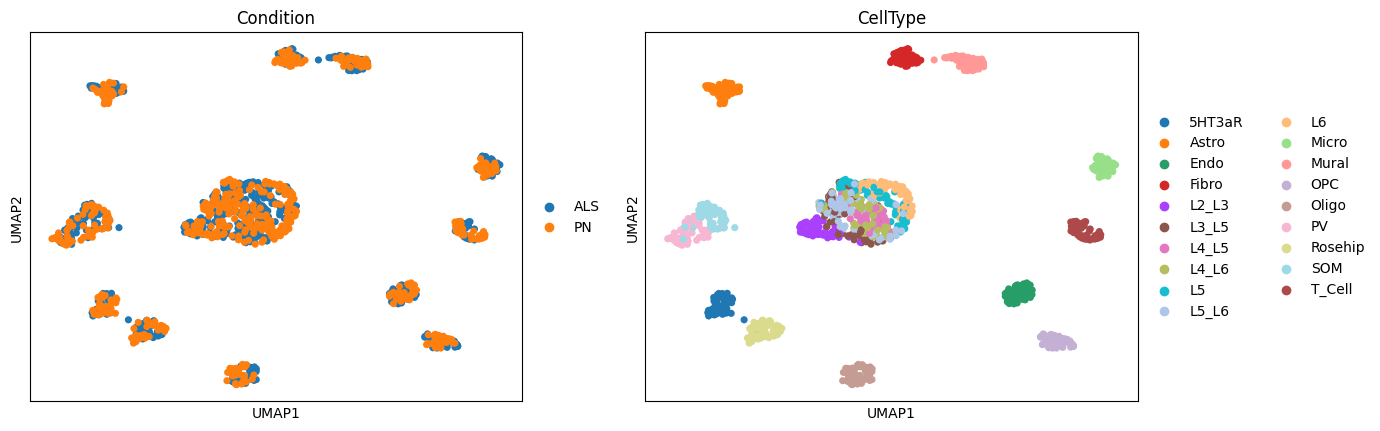

In [7]:
sc.pl.umap(adata, color=["Condition", "CellType"])

# Run after perturbation

To compute the embeddings on perturbed data, we copy the counts, and replace `adata.X` by the perturbation data:


In [ ]:
adata.layers["counts"] = adata.X.copy()
adata.X = adata.layers["perturbation"]

Then, we simply re-run Genformer, and store the embeddings in `adata.obsm["X_Geneformer_perturbed"]`.


In [ ]:
dataset = geneformer_v2.process_data(adata)
adata.obsm["X_Geneformer_perturbed"] = geneformer_v2.get_embeddings(dataset)

2026-03-02 10:04:52,978 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-03-02 10:04:53,139 - INFO:helical.utils.mapping:Mapped 22801 / 22832 genes to Ensembl IDs.
2026-03-02 10:04:53,178 - INFO:helical.models.geneformer.geneformer_tokenizer:AnnData object with n_obs × n_vars = 1140 × 22832
    obs: 'Sample_ID', 'Donor', 'Region', 'Sex', 'Condition', 'Group', 'C9_pos', 'CellClass', 'CellType', 'SubType', 'full_label', 'DGE_Group', 'Bakken_M1', 'data_merge_id', 'data_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'Cellstates_LVL1', 'Cellstates_LVL2', 'Cellstates_LVL3', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'Biotype', 'Chromosome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ENSID', 'mt', 'n_cells', 'biotype', 'index', 'ensembl_id', 'ensembl_id_collapsed'
    uns: 'CellType_colors', 'C

  0%|          | 0/48 [00:00<?, ?it/s]

2026-03-02 10:27:31,296 - INFO:helical.models.geneformer.model:Finished getting embeddings.


Finally, we save our results.


In [23]:
adata.write_h5ad("adata_embedded.h5ad")